In [ ]:
import sys
import os

# 1. Check if colab is already working
if 'google.colab' in str(get_ipython()):
    # Import both the url of the repository and its name
    REPO_URL = "https://github.com/aledelma99/DQN-Project"
    REPO_NAME = "DQN-Project"

    # Clone the repository inside colab if not present
    if not os.path.exists(REPO_NAME):
        !git clone {REPO_URL}

    # Set up the path for the checkpoints inside the cloned GitHub repo
    project_path = f"/content/{REPO_NAME}"
    checkpoint_path = os.path.join(project_path, "checkpoints")

    # Move inside the GitHub repository folder
    os.chdir(project_path)
    print("Repository cloned correctly!")
else:
    # If running locally on PC
    project_path = os.getcwd()
    checkpoint_path = os.path.join(project_path, "checkpoints")

# Check if the checkpoint folder exists
os.makedirs(checkpoint_path, exist_ok=True)

# Update the path in order to retrieve the .py file
if project_path not in sys.path:
    sys.path.append(project_path)


# Import the functions used to plot the tests' results and the final experiments on the test
from DQN_tools import plot_experiments_grid_universal, test_all_experiments_aggregated

print("Workplace correctly loaded for Testing!")
print(f"The evaluation weights will be loaded from: {checkpoint_path}")

Mounted at /content/drive
Import executed with success 'DQN project V3' - Copia!


In [ ]:
!pip install swig
!pip install gymnasium[box2d]
import importlib
import subprocess
import sys


required_packages = [
    "gymnasium",
    "numpy",
    "torch",
    "matplotlib",
    "seaborn",
    "scipy"
]

for package in required_packages:
    try:
        importlib.import_module(package)
    except ImportError:
        print(f" The library '{package}' was not found, install it")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f" '{package}' is installed")

print("\n Import all the necessary libraries")

import os
import random
import time
from collections import deque
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.autograd as autograd
from torch.autograd import Variable
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import zipfile



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.8 MB/s eta 0:00:00

 Import all the necessary libraries


(5) Experiments detected: ['baseline_hard', 'baseline_soft', 'high_tau_soft', 'low_lr_hard', 'low_lr_soft']

Grid graph successfully saved as: 'Complete experiment grid.png'


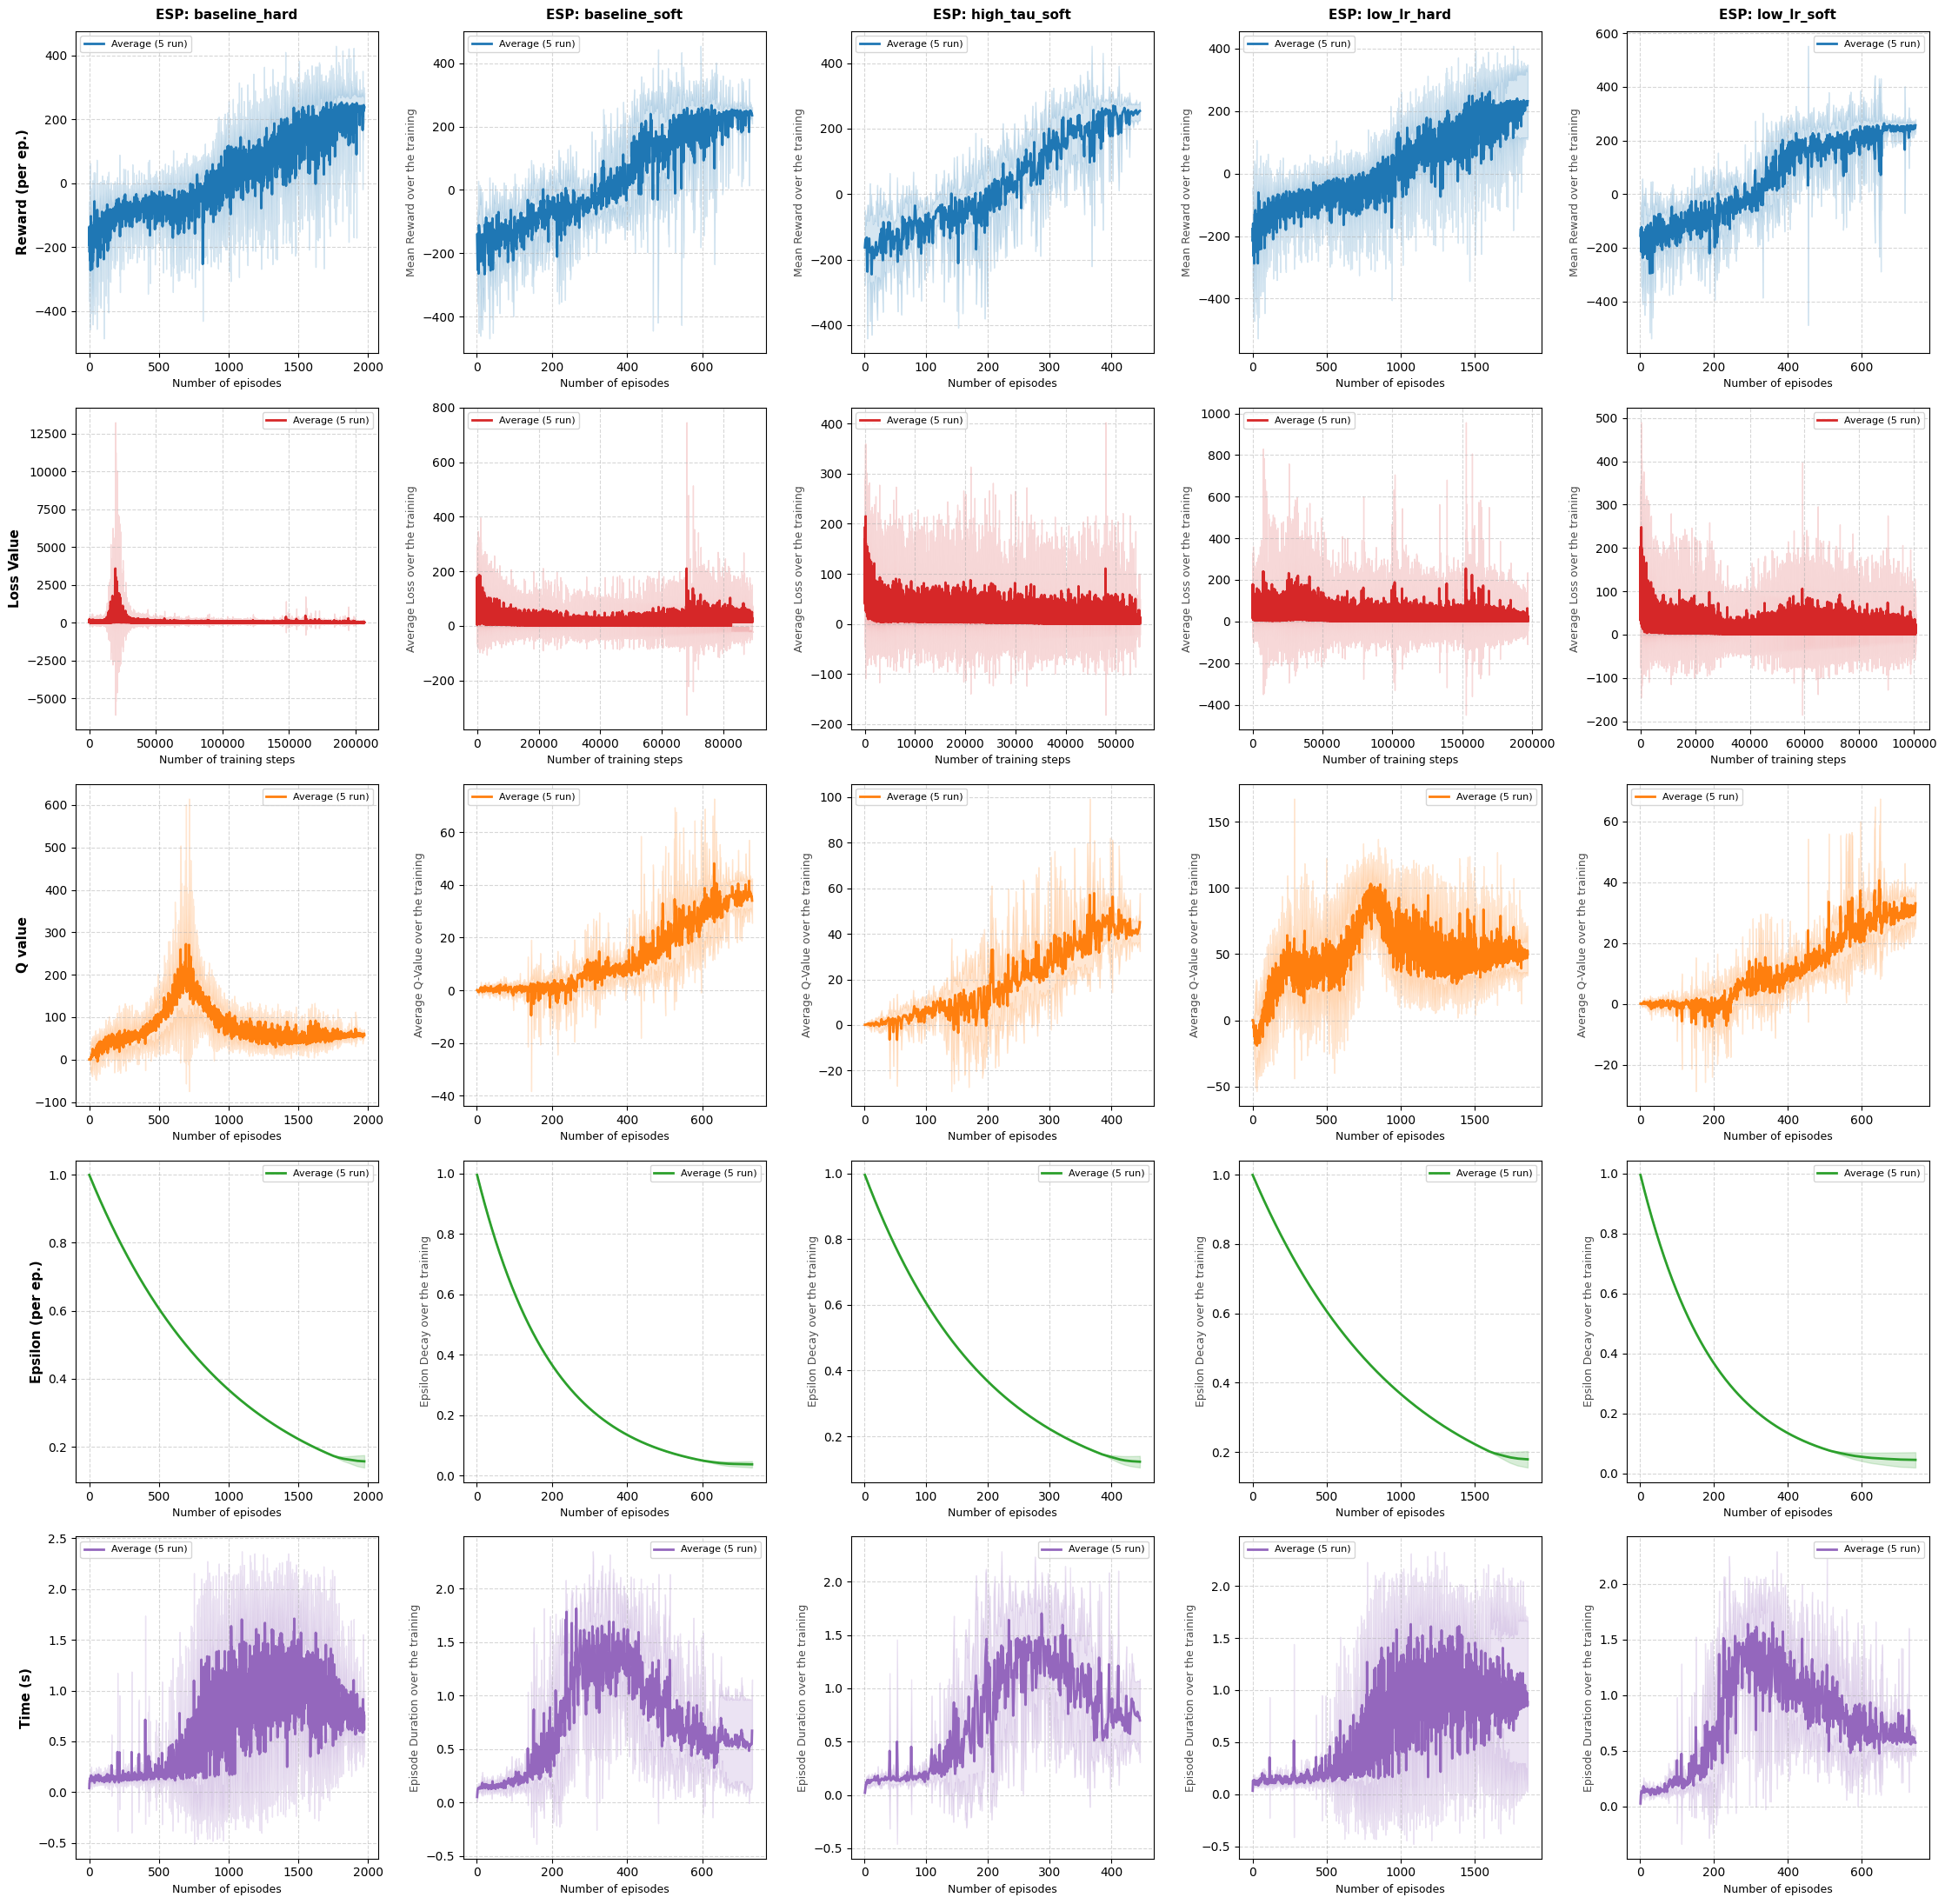

In [ ]:
# Plot the graphs of the training sessions using he metrics previously computed
plot_experiments_grid_universal(checkpoint_dir=checkpoint_path, eval_freq=50)

This cell is used to comment the results based on the data gathered during the training session.
The following metrics were used:
*   **Reward per episode**;
*   **Loss Function's Value**;
*   **Average Q**;
*   **Epsilon Decay**;
*   **Episodes' length**.  

The reason why these metrics were gathered is to analyze how different configurations behave during the training; analyzing for example which configuration converges first or which one has the longest episodes.  
Based on what is contained inside the **configurations** dictionary inside *Training.ipynb*, 5 five configurations are going to be evaluated, whose main difference is the usage of either the *soft* or *hard* rule to update the target neural network.  
The data plotted inside these graphs uses as x-axis the number of episodes (epochs), (except for the *Loss Function*whose value is computed inside every t-step of an episode), while in the y-axis the specific metric is placed.  
The plotted data are the average among all the checkpoints in which the environment was solved, the standard deviation of this mean values was computed to plot the confidence intervals.  
Given the possibility that the different training sessions of an experiment could have not lasted the same number of epochs, the longest run was taken,
and **Last-Value Padding** was applied to fill with the last recorded number the empty cells.  
**Rewards**   
Looking at the *Rewards'* evolution, all the configurations managed to reach a stable value of score near 200 somewhen. It can be seen that the configurations whose target's update rule is == **soft** have less oscillations with respect to the configurations based on the **hard** update; the same can be slightly seen looking at their confidence intervals. But, due to the stocasticity of the environment, these rewards are not stable (even advanced phases of the training, there are cases in which the rewards are extremely low) , and the resulting plots became a bit noisy.  All the configurations converge to approximately the same value due to the stopping condition of the training  based on the episode's score *(Average score over the last 100 episodes > 200)*. It's worth mention that the configurations based on the **hard_update** converged way less quickly with respect the other group, with a for the **low_lr_hard** due to its low learning rate $\alpha$.  
**Loss Function**  
The second row contains the graphs related to the *Loss Function*. Across all setups, the loss drops close to zero, proving that the agents are learning correctly to minimize the difference between q_target and q_expected. The biggest spike happens in **baseline_hard**, This behaviour may be related to optimistic Q-value estimates during the early stages of training, although other factors such as random initialization and target-network mismatch may also contribute. On the other hand, the soft update models show much smoother curves probably due to the constant target blending, which can prevents sudden shocks.   
Finally, the **low_lr_hard** configuration follow a similar path with respect to the soft update models, but with the presence of more instability at the end (possibly due to late exploration).  
**Average Q-function**  
In the third row, the *Average Q function* using a fixed sample of random states is plotted. One of the first thing that can be noted is the fact the configurations based on *hard* update converges to highest values compared to the ones using the *soft* update rule. While still talking about the hard update based configurations, both of them faced a sharp increase and decrease in the steps between 500 and 1000. This may happened due to an over estimation of the Q function. Given that the networks are initialized with random weights  it is possible that the agent overestimated the values for some actions (due to the max function). The result is that the agent believed that specific actions have an higher value, updating the weights using these wrong estimates, while the frozen target network caused the same target estimates to be reused for several consecutive updates, increasing the persistence of the estimation error. As more experience was collected and the replay buffer became more representative of the environment dynamics, the Q estimates gradually moved toward more stable values. The model with the higher learning rate exhibits a sharper increase (due to the larger step size amplifying the impact of the error) and reaches its peak more rapidly.
Conversely, the other configuration shows a slower, more gradual increase but features wider confidence intervals a possible signal of higher variance among the Q-function estimates across the different runs.  
The convergence of soft configurations at lower average Q-values may be probably driven by the continuous target network updates, which act as a statistical low-pass filter. This mechanism smothers localized overestimations from the max operator at every single step, preventing the error from an accumulating process as the one seen in the hard configurations and, enabling more realistic estimates.  
**Epsilon Decay**  
These graphs illustrate the behavior of the epsilon decay during the training phase, computed as the maximum between the minimum epsilon and the product of the current epsilon and the decay factor.
Notably, the *hard-update* configurations require a larger number of episodes to decay, which is due to a more conservative decay factor. In previous tests, using the same decay factor as the soft-update configurations caused exploration to end prematurely in the early phases before the agent could learn optimal actions, ultimately leading to a failure to converge within 2,000 episodes. By slowing down the decay, even the hard configurations successfully reached convergence within the maximum number of episodes, albeit at the cost of a slower learning process and higher epsilon values when the stop condition was met.  
The only two configurations that nearly reached the minimum epsilon floor (0.01) are *baseline_soft* and *low_lr_soft*. The latter, along with low_lr_hard, exhibits wider confidence intervals near the end of their curves. It can also be noted that in every configuration except *baseline_soft*, the final part of the curves show variance in their values at the end of the training. This probably happened due to the convergence at a different number of episodes and the padding technique applied to have arrays of the same length, which filled these latters using the last registered numbers. For this reason, the variance of the final values of epsilon increased, resulting in these larger confidence intervals.  
In the case of *baseline_soft* this is not happened because all the runs ended almost in the same epoch.  
**Episode Length (s)**  
This last metric analyzed is the average length expressed in seconds over the training of all these configurations.  
Time tracking was implemented using the *time* library, which records the system clock at the beginning and end of each episode to calculate total duration.  
Across all the configurations, it can be seen that the initial episodes lasted only a short time, because at the beginning the agent did not know how to behave, resulting in rapid crashes on the ground or failing in landing in the right spot.  
With time the length started to increase, a signal that the agent is learning how act properly in the situations it was facing, probably beginning to understand how to behave given specific situations.  
The growth trend then stopped, inducing an opposite one of decreasing time per episode, suggesting that the agent learned more efficient trajectories toward successful landings.
This phenomenon is less visible in the *hard-based* configurations, where  the average of the length is way less stable compared to the one of *soft-based* models when the time started to increase.  
This behaviour is probably induced by the over estimation of the Average Q seen in the third row.  
From the other hand, the *soft-based* configurations seems to be immune from the previously mentioned situation, learning how to win quickly way before reaching the training's ending condition, enabling this sharp length decrease.  
This event did not happen for the *hard-based* configurations, probably because the agents did not have the time during the training to learn strategies to end the episodes as fast as the other agents.

In [ ]:
# Test part
test_all_experiments_aggregated(
    checkpoint_dir=checkpoint_path,
    env_name='LunarLander-v3',
    state_size=8,
    action_size=4,
    num_test_episodes=400,
    success_threshold=200
)

 The test simulation for 5 experiments is begun...


,Experiment,Runs Tested,Mean Success Rate,Global Mean Reward,Average Std Reward
0,baseline_hard,5,84.2%,227.67,64.76
1,baseline_soft,5,63.3%,178.16,99.18
2,high_tau_soft,5,77.9%,211.98,71.11
3,low_lr_hard,5,87.1%,236.42,55.28
4,low_lr_soft,5,64.1%,194.35,74.16


,Experiment,Runs Tested,Mean Success Rate,Global Mean Reward,Average Std Reward
0,baseline_hard,5,84.2%,227.67,64.76
1,baseline_soft,5,63.3%,178.16,99.18
2,high_tau_soft,5,77.9%,211.98,71.11
3,low_lr_hard,5,87.1%,236.42,55.28
4,low_lr_soft,5,64.1%,194.35,74.16


### Evaluation and Testing

**Judgment Criteria**
To evaluate the efficacy of the learned policies, a final testing phase consisting of 400 episodes was executed with epsilon strictly set to 0. In this deterministic deployment phase, the agents operate in pure exploitation mode, always taking the action that maximizes the expected cumulative discounted reward from any given state.
To obtain a robust statistical baseline, each configuration was evaluated across 5 independent runs , and their results were averaged. In line with the standard LunarLander-v3 environment benchmarks, an episode is classified as a **success** if the final cumulative score is equal to or greater than 200 points; otherwise, it is considered a failure. Consequently, the primary metric used to rank the configurations is the *Mean Success Rate*.

**Results Analysis**  

As demonstrated by the testing results table, the hard-update configurations significantly outperformed their soft-update counterparts. The *low_lr_hard* model achieved the highest performance with a Mean Success Rate of 87.1% and a Global Mean Reward of 236.42, followed closely by the *baseline_hard* configuration at 84.2%. In addition, these hard-update setups also exhibited the lowest standard deviations (*Average Std Reward*), proving that their final policies are not only high-performing but also highly consistent.

These findings suggest that despite a more chaotic training phase characterized by prolonged episode lengths and severe Q-value overestimation, the hard-update agents ultimately developed more resilient and decisive policies. Conversely, the soft-update group, with its more stable learning dynamics, led to estimates more conservative and maybe also prevent the discovering of more efficient policies. This hypothesis may supported by the behavior of the *high_tau_soft* configuration. By utilizing a higher interpolation parameter (**tau = 0.005**), this agent allowed larger target network shifts, partially resembling the behavior of hard-update configurations and subsequently overcome the rest of the soft pool, reaching a 77.9% success rate.

**Improvement Proposals**  

To enhance the performance of the soft-update configurations, a possible approach would be to slow down their training process by tuning the epsilon decay factor. Forcing a wider exploration window could prevent premature convergence and allow these continuous models to discover optimal actions. Additionally, following the success of the *high_tau_soft* variant, systematically increasing the $\tau$ parameter across the other soft configurations could decrease the performance gap with the hard-update models.

Regarding the hard-update group, future work could test a slight reduction of the discount factor ($\gamma$). Lowering $\gamma$ would shorten the agent's effective horizon, potentially mitigating the backward propagation of the max operator's overestimation bias. Lastly, the performance of *low_lr_hard* suggests that lowering the learning rate ($\alpha$) may be beneficial for hard configurations, it could be an idea to reduce it in both configurations and look at the difference in the performances.
